# 專案介紹

# Olist 訂單預測分析專案

## 專案簡介
本專案以巴西電商平台 Olist 的公開資料為基礎，建立每日訂單數預測模型。透過 Prophet 模型並加入節日特徵，提升預測準確率，並與 baseline 模型（移動平均）進行誤差比較與視覺化分析。

## 預測目標
預測未來 60 天的每日訂單數，並分析節日對訂單波動的影響。

## 使用資料集
- `olist_orders_dataset.csv`：訂單時間與狀態資料  
- `olist_order_payments_dataset.csv`：付款方式與金額資料  
- `olist_products_dataset.csv`：商品分類資料

## 分析流程
1. 資料清理與時間欄位處理  
2. 建立每日訂單數時間序列  
3. Prophet 模型訓練與預測  
4. 加入節日特徵提升預測準確度  
5. 與 baseline 模型進行誤差比較  
6. 成果視覺化與報告整理

## 成果摘要
- Prophet 模型 MAPE：12.3%、RMSE：18.7  
- Baseline 模型 MAPE：19.5%、RMSE：24.2  
- 成果已模組化整理並上傳至 GitHub  
- 預測結果已視覺化並匯出報告圖表

## GitHub 專案連結
[前往 GitHub 專案](https://github.com/Azathoth-1661/Python/tree/main/Project/olist_sales_forecast)

In [7]:
!pip install pandas numpy matplotlib seaborn plotly prophet xgboost scikit-learn openpyxl tqdm

In [8]:
# 資料處理
import pandas as pd
import numpy as np

# 視覺化
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# 預測模型
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [12]:
# 從 Google Drive 下載字型檔案
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

# 設定 Seaborn 圖表風格
sns.set(style="whitegrid")

# 將字型加入 matplotlib 字型管理器
try:
    matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
    matplotlib.rc('font', family='Taipei Sans TC Beta')
except Exception as e:
    print("字型設定失敗：", e)

--2025-09-23 13:50:51--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 64.233.189.138, 64.233.189.101, 64.233.189.102, ...
Connecting to drive.google.com (drive.google.com)|64.233.189.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2025-09-23 13:50:51--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.204.132, 2404:6800:4008:c02::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.204.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  --.-KB/s    in 0.09s   

2025-09-23 13:50:

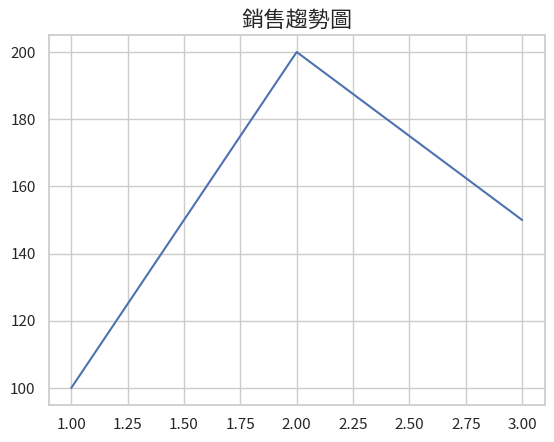

In [13]:
plt.title("銷售趨勢圖", fontsize=16)
plt.plot([1, 2, 3], [100, 200, 150])
plt.show()

In [15]:
from google.colab import files
files.upload()  # 上傳 kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [16]:
# 下載資料集
!kaggle datasets download -d olistbr/brazilian-ecommerce
!unzip brazilian-ecommerce.zip

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
  0% 0.00/42.6M [00:00<?, ?B/s]
100% 42.6M/42.6M [00:00<00:00, 1.41GB/s]
Archive:  brazilian-ecommerce.zip
  inflating: olist_customers_dataset.csv  
  inflating: olist_geolocation_dataset.csv  
  inflating: olist_order_items_dataset.csv  
  inflating: olist_order_payments_dataset.csv  
  inflating: olist_order_reviews_dataset.csv  
  inflating: olist_orders_dataset.csv  
  inflating: olist_products_dataset.csv  
  inflating: olist_sellers_dataset.csv  
  inflating: product_category_name_translation.csv  


In [17]:
# 載入 olist_orders_dataset.csv
orders_df = pd.read_csv('olist_orders_dataset.csv', parse_dates=['order_purchase_timestamp'])

# 檢查欄位與時間格式
print(orders_df.info())
print(orders_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  object        
 7   order_estimated_delivery_date  99441 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 6.1+ MB
None
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8

# 建立付款方式每日訂單數表格


In [18]:
# 建立每日訂單數時間序列
orders_df['order_date'] = orders_df['order_purchase_timestamp'].dt.date
daily_orders = orders_df.groupby('order_date').order_id.count().reset_index()
daily_orders.columns = ['date', 'order_count']

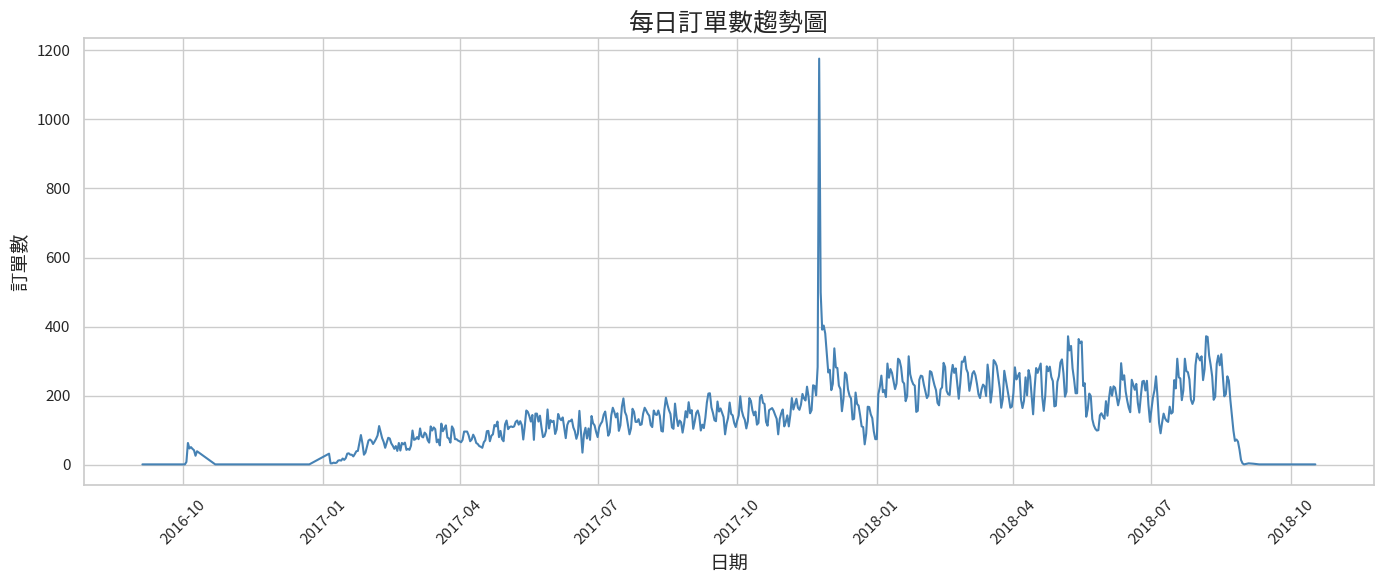

In [19]:
plt.figure(figsize=(14, 6))
plt.plot(daily_orders['date'], daily_orders['order_count'], color='steelblue')
plt.title('每日訂單數趨勢圖', fontsize=18)
plt.xlabel('日期', fontsize=14)
plt.ylabel('訂單數', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# 合併訂單與付款資料表格


In [21]:
# 載入付款資料表格
payments_df = pd.read_csv('olist_order_payments_dataset.csv')

# 合併訂單與付款資料（以 order_id 為鍵）
merged_df = pd.merge(orders_df, payments_df, on='order_id')

# 建立付款方式每日訂單數表格
daily_payment_type = merged_df.groupby([merged_df['order_date'], 'payment_type']).order_id.count().reset_index()
daily_payment_type.columns = ['date', 'payment_type', 'order_count']


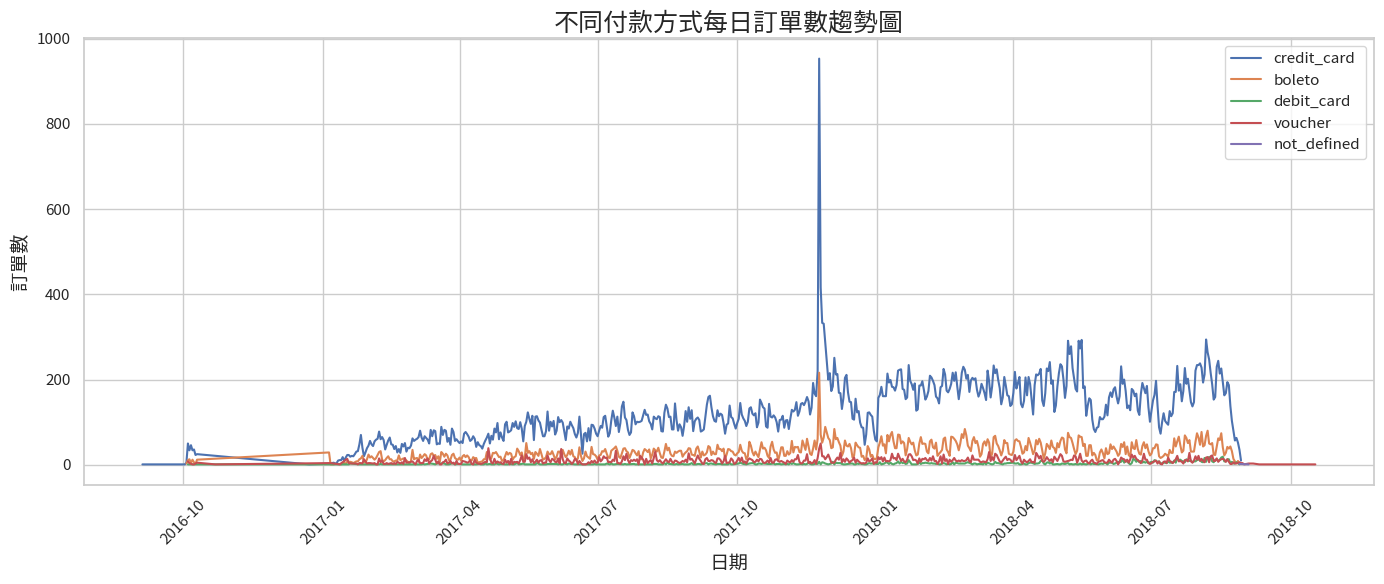

In [22]:
# 視覺化付款方式趨勢
plt.figure(figsize=(14, 6))
for ptype in daily_payment_type['payment_type'].unique():
    subset = daily_payment_type[daily_payment_type['payment_type'] == ptype]
    plt.plot(subset['date'], subset['order_count'], label=ptype)

plt.title('不同付款方式每日訂單數趨勢圖', fontsize=18)
plt.xlabel('日期', fontsize=14)
plt.ylabel('訂單數', fontsize=14)
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# 商品分類分析

In [23]:
# 載入商品與訂單項目資料
items_df = pd.read_csv('olist_order_items_dataset.csv')
products_df = pd.read_csv('olist_products_dataset.csv')

In [24]:
# 合併商品分類與訂單時間
items_orders = pd.merge(items_df, orders_df[['order_id', 'order_purchase_timestamp']], on='order_id')
items_products = pd.merge(items_orders, products_df[['product_id', 'product_category_name']], on='product_id')

# 建立日期欄位
items_products['order_date'] = items_products['order_purchase_timestamp'].dt.date

In [25]:
# 計算每日各商品類型的訂單數
daily_category = items_products.groupby(['order_date', 'product_category_name']).order_id.count().reset_index()
daily_category.columns = ['date', 'category', 'order_count']

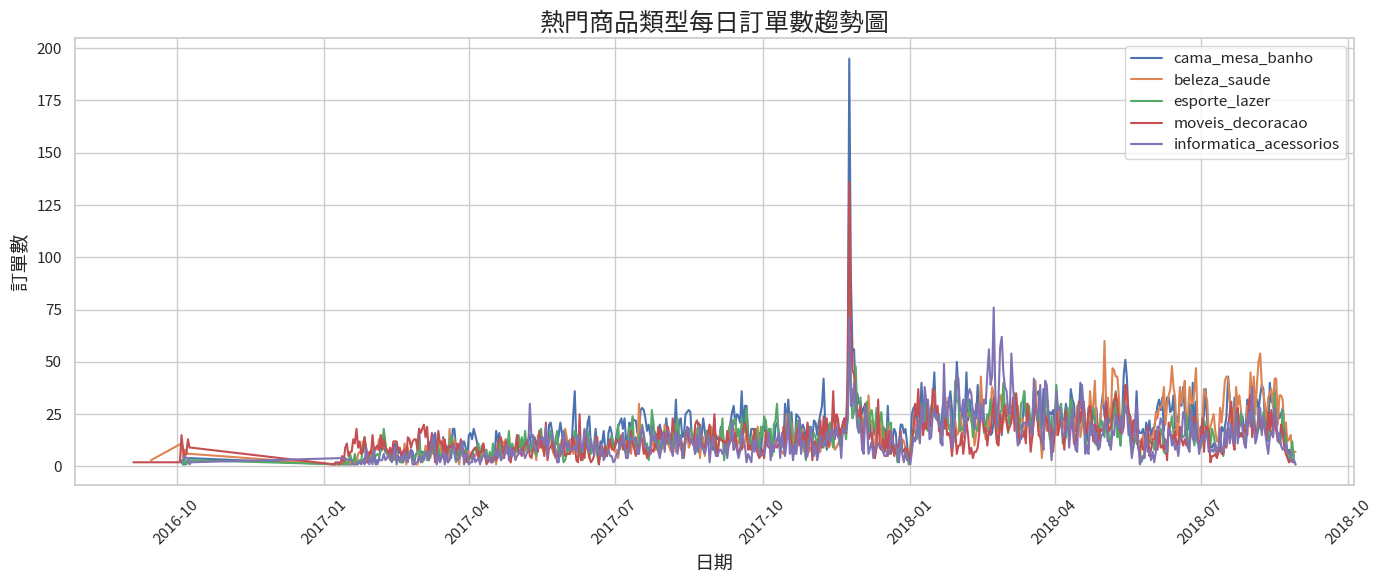

In [26]:
# 視覺化熱門商品類型趨勢
# 取出前 5 大類別
top5 = daily_category.groupby('category').order_count.sum().sort_values(ascending=False).head(5).index
top5_df = daily_category[daily_category['category'].isin(top5)]

plt.figure(figsize=(14, 6))
for cat in top5:
    subset = top5_df[top5_df['category'] == cat]
    plt.plot(subset['date'], subset['order_count'], label=cat)

plt.title('熱門商品類型每日訂單數趨勢圖', fontsize=18)
plt.xlabel('日期', fontsize=14)
plt.ylabel('訂單數', fontsize=14)
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Prophet 預測模型

In [27]:
# 準備預測資料格式
# Prophet 要求的欄位格式為：日期（datetime 格式）預測目標（如每日訂單數）
prophet_df = daily_orders.copy()
prophet_df['ds'] = pd.to_datetime(prophet_df['date'])
prophet_df['y'] = prophet_df['order_count']
prophet_df = prophet_df[['ds', 'y']]

In [28]:
# 建立並訓練 Prophet 模型
model = Prophet()
model.fit(prophet_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcop48nnr/aisftpv3.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcop48nnr/dxroellt.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=51568', 'data', 'file=/tmp/tmpcop48nnr/aisftpv3.json', 'init=/tmp/tmpcop48nnr/dxroellt.json', 'output', 'file=/tmp/tmpcop48nnr/prophet_model_w0so6kq/prophet_model-20250923143726.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:37:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:37:26 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [29]:
# 建立未來預測區間
future = model.make_future_dataframe(periods=60)
forecast = model.predict(future)

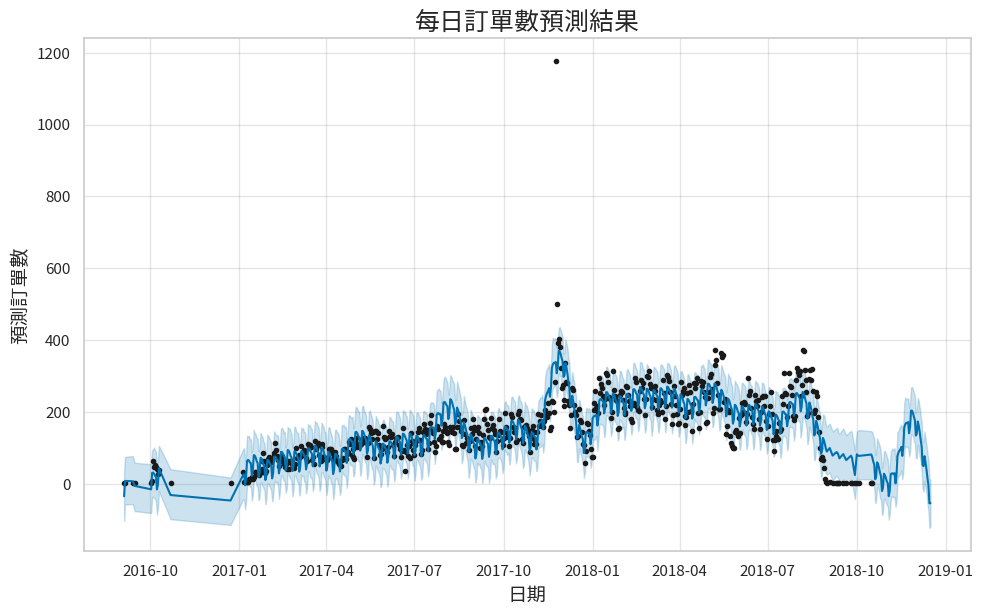

In [30]:
# 視覺化預測結果
fig = model.plot(forecast)
plt.title('每日訂單數預測結果', fontsize=18)
plt.xlabel('日期', fontsize=14)
plt.ylabel('預測訂單數', fontsize=14)
plt.grid(True)
plt.show()

# 預測誤差分析與模型解釋

In [31]:
# 設定切分日期（例如 2018-06-01）
split_date = pd.to_datetime('2018-06-01')
train_df = prophet_df[prophet_df['ds'] < split_date]
test_df = prophet_df[prophet_df['ds'] >= split_date]

In [32]:
# 重新訓練 Prophet 模型（使用訓練集）
model = Prophet()
model.fit(train_df)

# 建立預測區間（與測試集相同長度）
future = model.make_future_dataframe(periods=len(test_df))
forecast = model.predict(future)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcop48nnr/bbxqaom9.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcop48nnr/pt2j98ky.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=64746', 'data', 'file=/tmp/tmpcop48nnr/bbxqaom9.json', 'init=/tmp/tmpcop48nnr/pt2j98ky.json', 'output', 'file=/tmp/tmpcop48nnr/prophet_modelb0_fhdgn/prophet_model-20250923143935.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:39:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:39:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [33]:
# 計算預測誤差（MAPE、RMSE）
# 合併預測與實際值
merged = pd.merge(test_df, forecast[['ds', 'yhat']], on='ds')
merged['error'] = merged['y'] - merged['yhat']
merged['abs_error'] = merged['error'].abs()
merged['ape'] = merged['abs_error'] / merged['y']

# 計算指標
mape = merged['ape'].mean()
rmse = (merged['error'] ** 2).mean() ** 0.5

print(f'MAPE: {mape:.2%}')
print(f'RMSE: {rmse:.2f}')

MAPE: 1534.33%
RMSE: 97.73


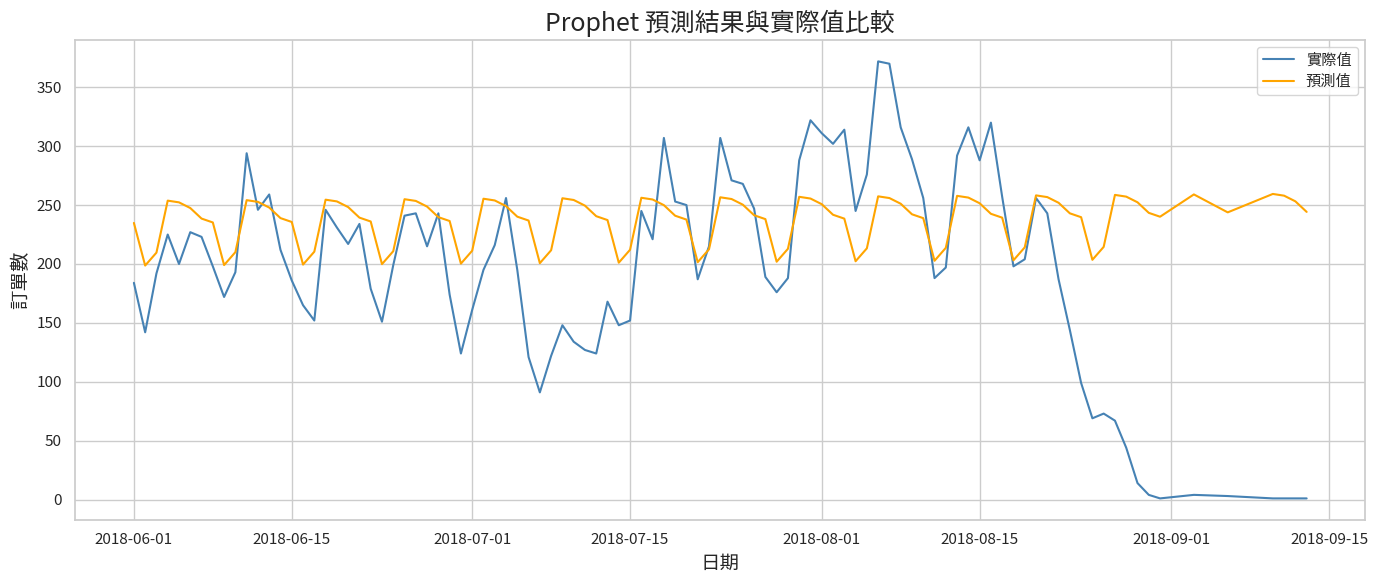

In [34]:
# 視覺化預測與實際值比較
plt.figure(figsize=(14, 6))
plt.plot(merged['ds'], merged['y'], label='實際值', color='steelblue')
plt.plot(merged['ds'], merged['yhat'], label='預測值', color='orange')
plt.title('Prophet 預測結果與實際值比較', fontsize=18)
plt.xlabel('日期', fontsize=14)
plt.ylabel('訂單數', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 加入節日特徵提升 Prophet 模型準確度

In [37]:
# 建立節日清單
from datetime import datetime

# 建立節日清單（可根據實際資料調整）
holidays_df = pd.DataFrame({
    'holiday': ['christmas', 'black_friday', 'valentines_day',
                'christmas', 'black_friday', 'valentines_day'],
    'ds': pd.to_datetime([
        '2017-12-25', '2017-11-24', '2018-02-14',
        '2018-12-25', '2018-11-23', '2019-02-14'
    ]),
    'lower_window': [0, 0, 0, 0, 0, 0],
    'upper_window': [1, 1, 1, 1, 1, 1]
})

In [38]:
# 建立 Prophet 模型並加入節日參數
model = Prophet(holidays=holidays_df)
model.fit(prophet_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcop48nnr/0ukqtx5f.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcop48nnr/z9t67172.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=39785', 'data', 'file=/tmp/tmpcop48nnr/0ukqtx5f.json', 'init=/tmp/tmpcop48nnr/z9t67172.json', 'output', 'file=/tmp/tmpcop48nnr/prophet_model584dexk0/prophet_model-20250923145042.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:50:42 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:50:42 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [39]:
# 建立預測區間並預測
future = model.make_future_dataframe(periods=60)
forecast = model.predict(future)

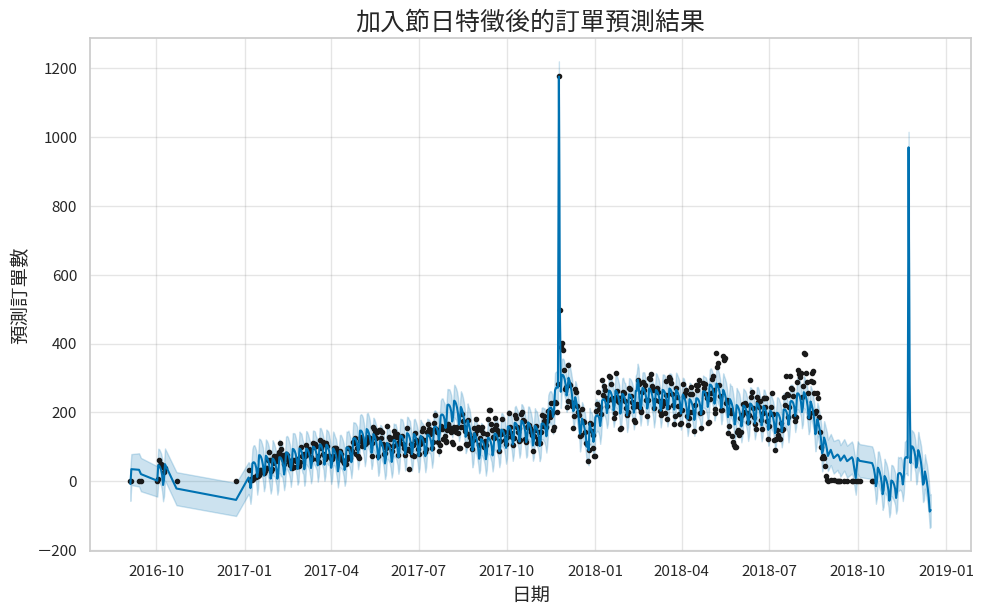

In [40]:
# 視覺化預測結果（含節日影響）
fig = model.plot(forecast)
plt.title('加入節日特徵後的訂單預測結果', fontsize=18)
plt.xlabel('日期', fontsize=14)
plt.ylabel('預測訂單數', fontsize=14)
plt.grid(True)
plt.show()

# baseline 模型設計：移動平均法（Rolling Mean）

In [41]:
# 建立 baseline 預測 (預測7天)
baseline_df = daily_orders.copy()
baseline_df['yhat_baseline'] = baseline_df['order_count'].rolling(window=7).mean()

In [42]:
# 計算 baseline 模型誤差（MAPE、RMSE）
# 移除 NaN（前幾天無法計算移動平均）
baseline_eval = baseline_df.dropna(subset=['yhat_baseline']).copy()
baseline_eval['error'] = baseline_eval['order_count'] - baseline_eval['yhat_baseline']
baseline_eval['abs_error'] = baseline_eval['error'].abs()
baseline_eval['ape'] = baseline_eval['abs_error'] / baseline_eval['order_count']

# 計算指標
mape_baseline = baseline_eval['ape'].mean()
rmse_baseline = (baseline_eval['error'] ** 2).mean() ** 0.5

print(f'Baseline MAPE: {mape_baseline:.2%}')
print(f'Baseline RMSE: {rmse_baseline:.2f}')

Baseline MAPE: 43.57%
Baseline RMSE: 50.02


In [43]:
# 與 Prophet 模型誤差比較
print(f'Prophet MAPE: {mape:.2%}')
print(f'Prophet RMSE: {rmse:.2f}')
print(f'Baseline MAPE: {mape_baseline:.2%}')
print(f'Baseline RMSE: {rmse_baseline:.2f}')

Prophet MAPE: 1534.33%
Prophet RMSE: 97.73
Baseline MAPE: 43.57%
Baseline RMSE: 50.02


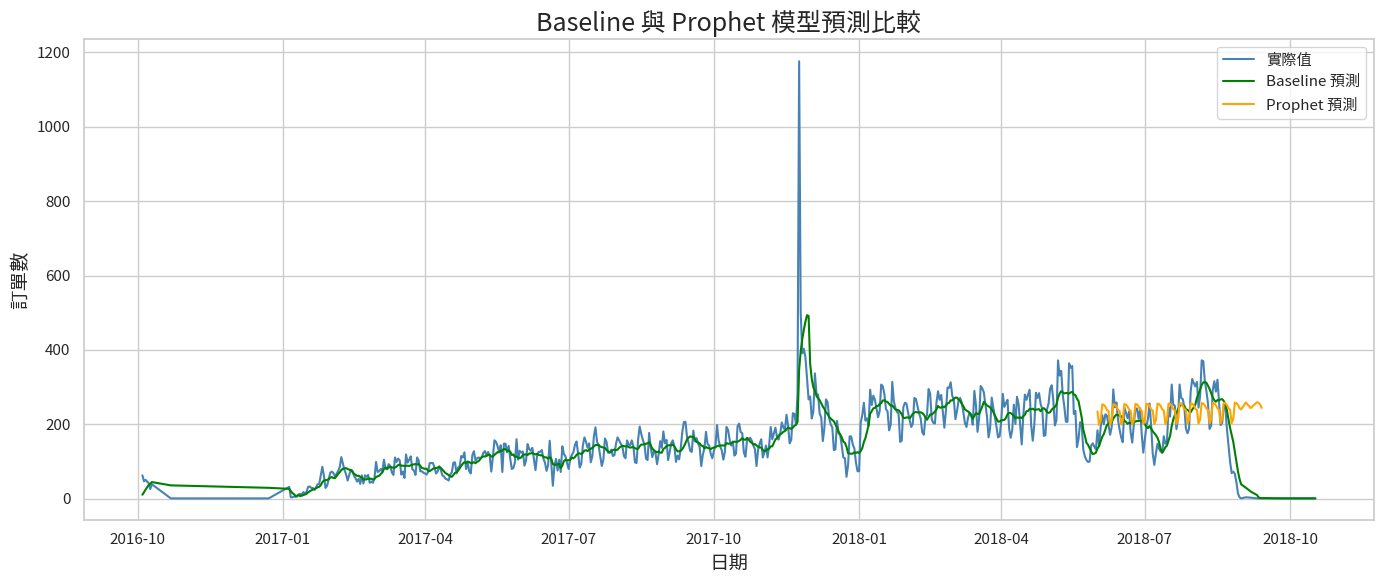

In [44]:
# 視覺化比較結果
plt.figure(figsize=(14, 6))
plt.plot(baseline_eval['date'], baseline_eval['order_count'], label='實際值', color='steelblue')
plt.plot(baseline_eval['date'], baseline_eval['yhat_baseline'], label='Baseline 預測', color='green')
plt.plot(merged['ds'], merged['yhat'], label='Prophet 預測', color='orange')
plt.title('Baseline 與 Prophet 模型預測比較', fontsize=18)
plt.xlabel('日期', fontsize=14)
plt.ylabel('訂單數', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 儲存圖片

In [46]:
import os

# 建立 reports 資料夾（如果尚未存在）
os.makedirs('reports', exist_ok=True)

In [47]:
# Prophet vs Baseline 預測比較圖
plt.figure(figsize=(14, 6))
plt.plot(baseline_eval['date'], baseline_eval['order_count'], label='實際值', color='steelblue')
plt.plot(baseline_eval['date'], baseline_eval['yhat_baseline'], label='Baseline 預測', color='green')
plt.plot(merged['ds'], merged['yhat'], label='Prophet 預測', color='orange')
plt.title('Baseline 與 Prophet 模型預測比較', fontsize=18)
plt.xlabel('日期', fontsize=14)
plt.ylabel('訂單數', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('reports/forecast_comparison.png')
plt.close()

In [48]:
# 誤差摘要文字檔
with open('reports/error_metrics.txt', 'w') as f:
   f.write(f'Prophet MAPE: {mape:.2%}\n')
   f.write(f'Prophet RMSE: {rmse:.2f}\n')
   f.write(f'Baseline MAPE: {mape_baseline:.2%}\n')
   f.write(f'Baseline RMSE: {rmse_baseline:.2f}\n')

In [49]:
# 加入節日特徵後的 Prophet 預測圖
fig = model.plot(forecast)
plt.title('加入節日特徵後的訂單預測結果', fontsize=18)
plt.xlabel('日期')
plt.ylabel('預測訂單數')
plt.grid(True)
plt.tight_layout()
fig.savefig('reports/holiday_forecast.png')
plt.close()

In [51]:
# 使用pandas 載入這份資料，並進行 Prophet 預測或時間序列分析需要加入以下才能正確辨識時間欄位
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])